In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
from tqdm import tqdm
from pprint import pprint

sc.set_figure_params(frameon=False, dpi=80, fontsize=12)

from utils.io import read_anndata, write_zarr
from utils.misc import dask_compute

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)


# Read Data

In [2]:
adata = read_anndata(
    'data/pipeline/qc/marker_genes/dataset~benchmark/file_id~collect:benchmark.zarr',
    layers='layers',
    obs='obs',
    var='var',
    obsm='obsm',
    uns='uns',
    obsp='obsp',
    dask_slots=['layers', 'X', 'obsp'],
    dask=True,
    backed=True,
)

dask: True, backed: True
chunks: (200000, -1)
Read slot "layers", store as "layers"...


Read layers slots as_dask=True:   0%|          | 0/2 [00:00<?, ?it/s]/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing CSRDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSRDataset instead.
  warnings.warn(msg, FutureWarning)
/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
Read layers slots as_dask=True: 100%|██████████| 2/2 [00:00<00:00, 113.34it/s]

Read slot "obs", store as "obs"...


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


Read obsm slots as_dask=False: 100%|██████████| 4/4 [00:00<00:00,  8.30it/s]

Read slot "uns", store as "uns"...


Read slot "obsp", store as "obsp"...


Read obsp slots as_dask=True:   0%|          | 0/4 [00:00<?, ?it/s]/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing CSRDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSRDataset instead.
  warnings.warn(msg, FutureWarning)
/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
Read obsp slots as_dask=True: 100%|██████████| 4/4 [00:00<00:00, 178.69it/s]

shape: (584944, 27957)


In [3]:
list(adata.obsm.keys())

['X_emb--metrics:label_transfer:clustering:preprocessing:HLCA',
 'X_emb--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC',
 'X_umap--metrics:label_transfer:clustering:preprocessing:HLCA',
 'X_umap--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC']

# UMAP sanity check

In [4]:
def plot_embedding(adata, colors, **kwargs):
    for color in colors:
        if color not in adata.obs.columns:
            continue
        sc.pl.embedding(
            adata,
            color=color,
            **kwargs,
        )

In [5]:
colors = [
    'ann_finest_level',
    'file_id',
    'study',
    'assay',
    'file_id--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC',
]

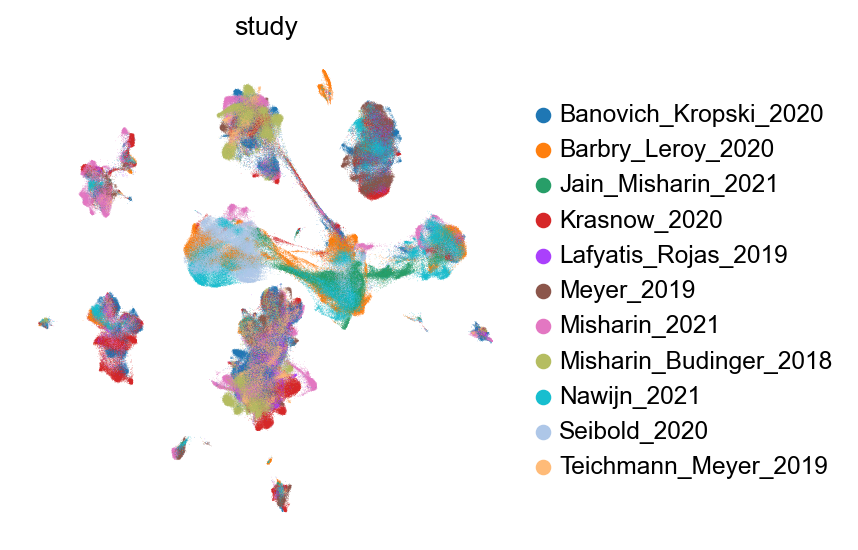

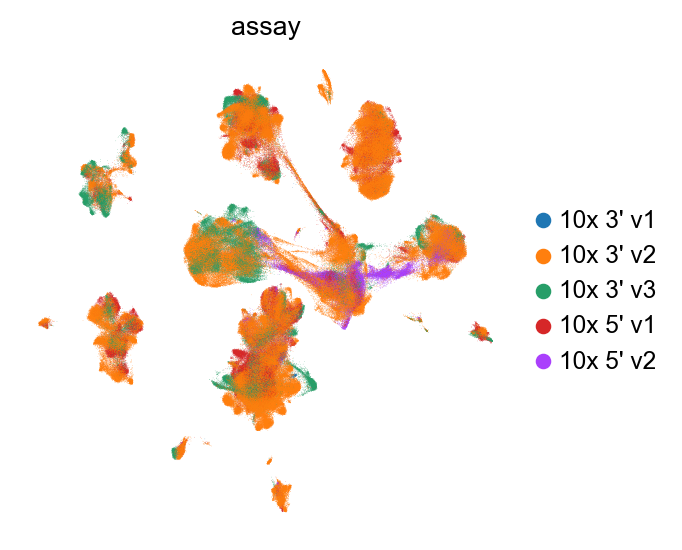

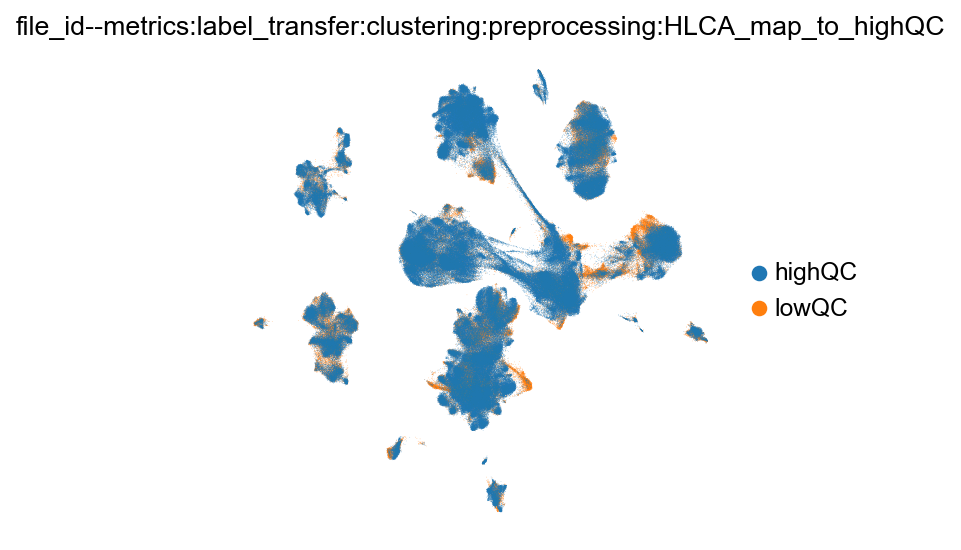

In [6]:
plot_embedding(
    adata,
    basis='X_umap--metrics:label_transfer:clustering:preprocessing:HLCA',
    colors=colors,
)

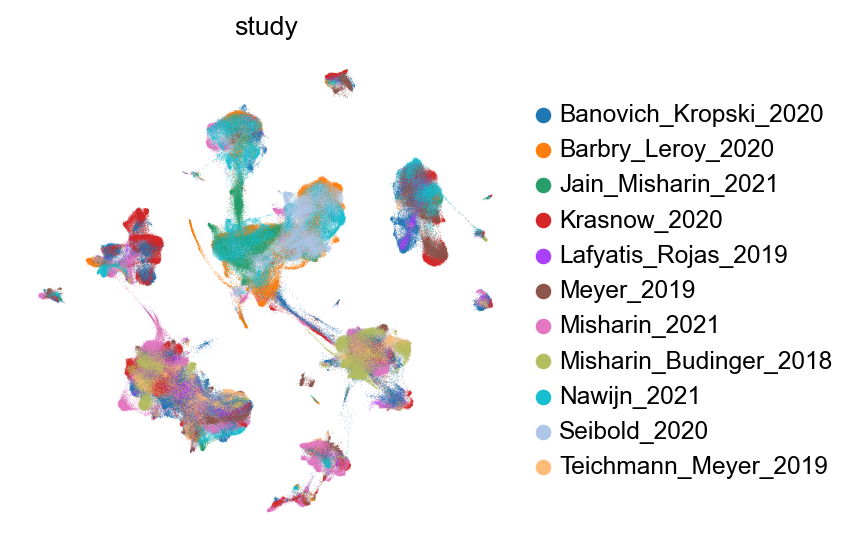

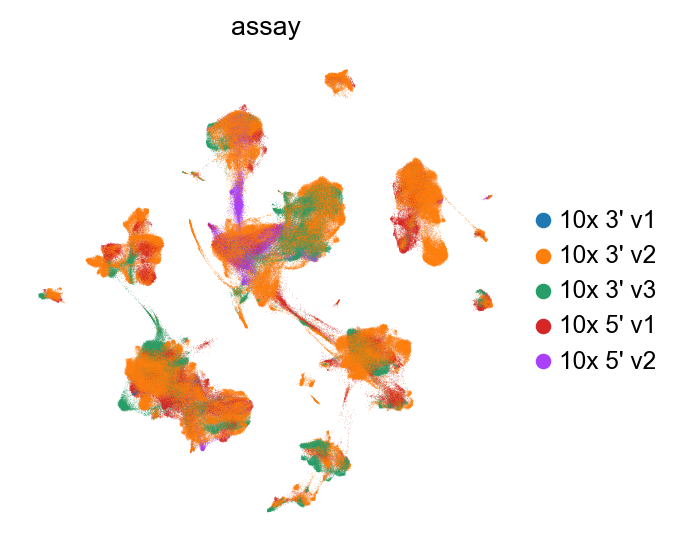

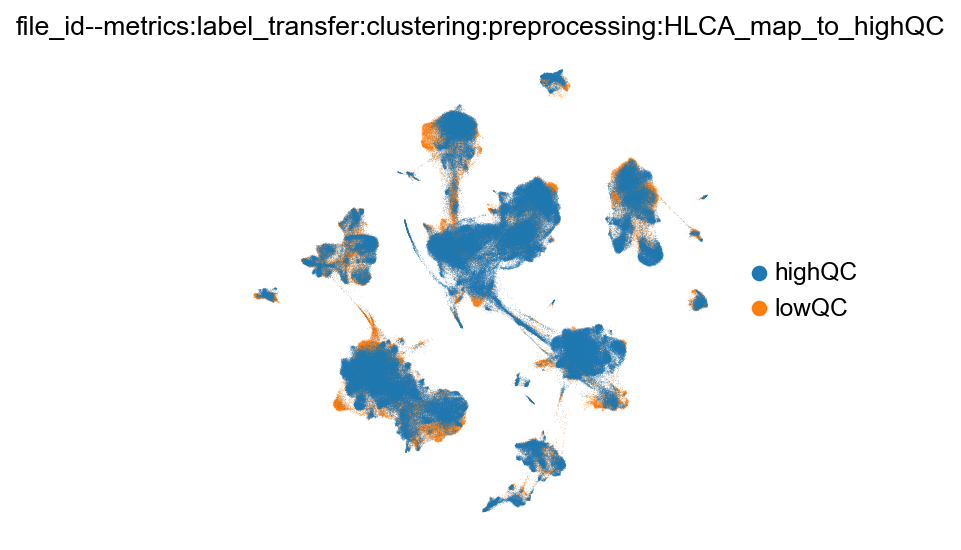

In [7]:
plot_embedding(
    adata,
    basis='X_umap--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC',
    colors=colors,
)

# Export

In [8]:
output_dir = 'data/output/export'
file_name = 'hlca_qc.zarr'

In [9]:
%%time
write_zarr(adata, f'{output_dir}/{file_name}')

CPU times: user 50.6 s, sys: 21 s, total: 1min 11s
Wall time: 1min 39s


In [10]:
!du -hs {output_dir}/{file_name}

4.4G	data/output/export/hlca_qc.zarr


In [11]:
!du -hd1 {output_dir}/{file_name} | sort -h

12K	data/output/export/hlca_qc.zarr/varm
12K	data/output/export/hlca_qc.zarr/varp
716K	data/output/export/hlca_qc.zarr/var
5.5M	data/output/export/hlca_qc.zarr/uns
80M	data/output/export/hlca_qc.zarr/obs
141M	data/output/export/hlca_qc.zarr/obsm
484M	data/output/export/hlca_qc.zarr/obsp
4.9G	data/output/export/hlca_qc.zarr/layers
5.5G	data/output/export/hlca_qc.zarr


In [12]:
!du -hd1 {output_dir}/{file_name}/layers | sort -h

2.4G	data/output/export/hlca_qc.zarr/layers/normcounts
2.5G	data/output/export/hlca_qc.zarr/layers/counts
4.9G	data/output/export/hlca_qc.zarr/layers


In [13]:
!du -hd1 {output_dir}/{file_name}/obsm | sort -h

4.0M	data/output/export/hlca_qc.zarr/obsm/X_umap--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC
4.1M	data/output/export/hlca_qc.zarr/obsm/X_umap--metrics:label_transfer:clustering:preprocessing:HLCA
67M	data/output/export/hlca_qc.zarr/obsm/X_emb--metrics:label_transfer:clustering:preprocessing:HLCA
67M	data/output/export/hlca_qc.zarr/obsm/X_emb--metrics:label_transfer:clustering:preprocessing:HLCA_map_to_highQC
141M	data/output/export/hlca_qc.zarr/obsm


In [14]:
%%time
!cd {output_dir} && tar cf - {file_name} | lz4 -f -9 - {file_name}.tar.lz4

Compressed 8204615680 bytes into 7011671957 bytes ==> 85.46%                   
CPU times: user 1.23 s, sys: 252 ms, total: 1.48 s
Wall time: 4min 18s


In [15]:
ll {output_dir}

total 153280124
-rw-r--r--  1 michaela.mueller  3811286419 Nov 10 03:59 hica_cxg_pseudobulk.h5ad
-rw-r--r--  1 michaela.mueller        2798 Nov 13 01:50 hica_DC_hyperparams.csv
drwxr-xr-x 11 michaela.mueller        4096 Nov 13 01:49 hica_dcs.zarr/
-rw-r--r--  1 michaela.mueller  1286973940 Nov 13 01:50 hica_dcs.zarr.tar.lz4
-rw-r--r--  1 michaela.mueller        5964 Nov 18 04:33 hica_global_cxg_hyperparams.csv
drwxr-xr-x 10 michaela.mueller        4096 Nov 18 03:46 hica_global_cxg.zarr/
-rw-r--r--  1 michaela.mueller 73059609207 Nov 18 04:33 hica_global_cxg.zarr.tar.lz4
-rw-r--r--  1 michaela.mueller        3390 Nov 12 07:24 hica_global_hyperparams.csv
drwxr-xr-x 11 michaela.mueller        4096 Nov 12 07:39 hica_global.zarr/
-rw-rw-r--  1 michaela.mueller 71816131638 Nov 12 08:16 hica_global.zarr.tar.lz4
drwxr-xr-x 10 michaela.mueller        4096 Nov 20 06:16 hlca_qc.zarr/
-rw-r--r--  1 michaela.mueller  7011671957 Nov 20 06:20 hlca_qc.zarr.tar.lz4


In [16]:
!echo rclone copy -P {output_dir}/{file_name}.tar.lz4 onedrive:scAtlasTb/HLCA

rclone copy -P data/output/export/hlca_qc.zarr.tar.lz4 onedrive:scAtlasTb/HLCA
